# Week 8 PBA — Sentiment Analysis: Berita MBG

**Analisis Sentimen Berita Makan Bergizi Gratis (MBG)**

Notebook ini menggabungkan dua dataset:
- `preprocessed_articles.csv` — hasil scraping berita MBG (Week 6)
- `dataset_label.csv` — label sentimen manual (sebagian; digunakan sebagai evaluasi)

**Pendekatan:**
1. Load & merge kedua dataset via kolom `link`
2. Eksplorasi data (EDA)
3. Sentiment analysis menggunakan **IndoBERT** (pretrained)
4. Evaluasi terhadap label manual yang tersedia
5. Visualisasi hasil

## 1. Setup & Import

In [24]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from wordcloud import WordCloud
from collections import Counter
import re

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
import torch
from tqdm.auto import tqdm

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
device = 0 if torch.cuda.is_available() else -1
print(f"Device used     : {'GPU' if device == 0 else 'CPU'}")

PyTorch version : 2.10.0+cu128
CUDA available  : True
Device used     : GPU


## 2. Load Dataset

In [25]:
# Load scraping results (Week 6)
df_articles = pd.read_csv('../tugas-week-6/preprocessed_articles.csv')
print(f"Articles shape : {df_articles.shape}")
print(f"Columns        : {df_articles.columns.tolist()}")
df_articles.head(3)

Articles shape : (340, 5)
Columns        : ['judul', 'link', 'portal_berita', 'text_berita', 'text_berita_clean']


,judul,link,portal_berita,text_berita,text_berita_clean
0,Wamendukbangga: Distribusi MBG untuk Ibu Hamil...,https://tribratanews.polri.go.id/blog/nasional...,Tribrata,Tribratanews.polri.go.id– Jakarta. Wakil Mente...,tribratanews polri go id jakarta wakil menteri...
1,Makan Gratis dan Pertaruhan Politik Anggaran |...,https://www.tempo.co/kolom/mbg-dan-pertaruhan-...,Tempo,Iklan\nBerita Tempo Plus\nHandi Risza\nWakil R...,wakil rektor universitas paramadina lulus prog...
2,Pedagang Melon di Pasar Gede Solo Rasakan Peni...,https://www.liputan6.com/regional/read/6310544...,Liputan6,"Pedagang buah di Pasar Gede Hardjonagoro Solo,...",dagang buah pasar gede hardjonagoro solo rasa ...


In [26]:
# Load label dataset
df_label = pd.read_csv('dataset_label.csv')
print(f"Labels shape   : {df_label.shape}")
print(f"Columns        : {df_label.columns.tolist()}")
print("\nLabel distribution:")
print(df_label['label'].value_counts(dropna=False))
df_label.head(3)

Labels shape   : (334, 3)
Columns        : ['label', 'title', 'link']

Label distribution:
label
Positif    114
Negatif    111
Netral     107
NaN          2
Name: count, dtype: int64


,label,title,link
0,Positif,Wamendukbangga: Distribusi MBG untuk Ibu Hamil...,https://tribratanews.polri.go.id/blog/nasional...
1,Negatif,Makan Gratis dan Pertaruhan Politik Anggaran |...,https://www.tempo.co/kolom/mbg-dan-pertaruhan-...
2,Positif,Pedagang Melon di Pasar Gede Solo Rasakan Peni...,https://www.liputan6.com/regional/read/6310544...


## 3. Merge Datasets

In [27]:
# Join on 'link' — inner join to keep articles that have both text and label slot
df = df_articles.merge(
    df_label[['link', 'label']],
    on='link',
    how='inner'
)

print(f"Merged shape   : {df.shape}")
print(f"Labeled rows   : {df['label'].notna().sum()}")
print(f"Unlabeled rows : {df['label'].isna().sum()}")
df.head(3)

Merged shape   : (333, 6)
Labeled rows   : 331
Unlabeled rows : 2


,judul,link,portal_berita,text_berita,text_berita_clean,label
0,Wamendukbangga: Distribusi MBG untuk Ibu Hamil...,https://tribratanews.polri.go.id/blog/nasional...,Tribrata,Tribratanews.polri.go.id– Jakarta. Wakil Mente...,tribratanews polri go id jakarta wakil menteri...,Positif
1,Makan Gratis dan Pertaruhan Politik Anggaran |...,https://www.tempo.co/kolom/mbg-dan-pertaruhan-...,Tempo,Iklan\nBerita Tempo Plus\nHandi Risza\nWakil R...,wakil rektor universitas paramadina lulus prog...,Negatif
2,Pedagang Melon di Pasar Gede Solo Rasakan Peni...,https://www.liputan6.com/regional/read/6310544...,Liputan6,"Pedagang buah di Pasar Gede Hardjonagoro Solo,...",dagang buah pasar gede hardjonagoro solo rasa ...,Positif


## 4. Exploratory Data Analysis (EDA)

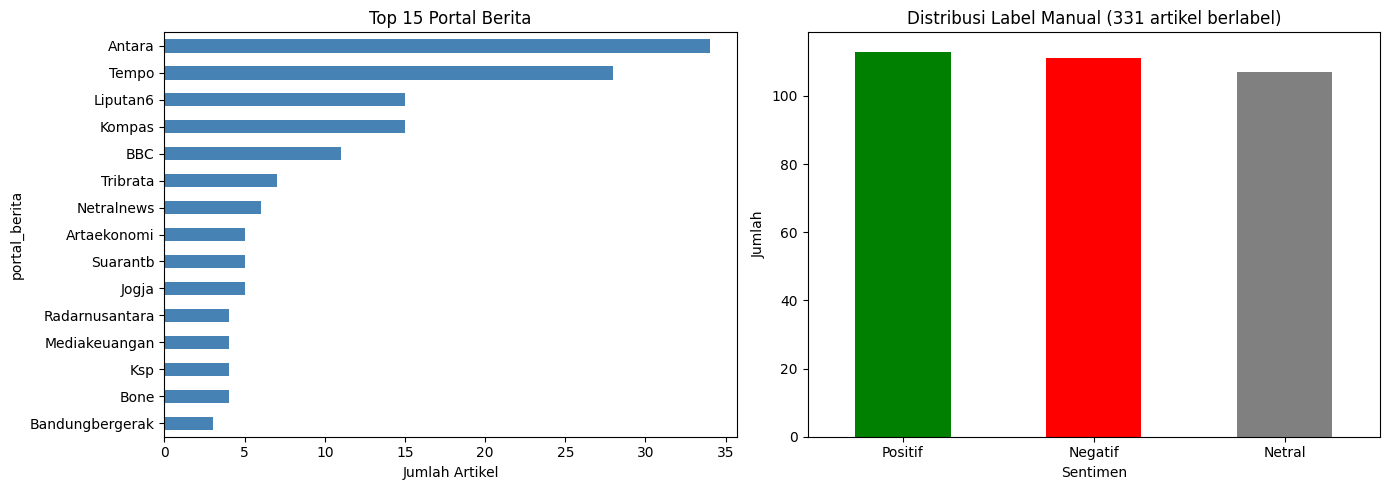

In [28]:
# Distribution of news portals
portal_counts = df['portal_berita'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Portal distribution
portal_counts.head(15).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Portal Berita')
axes[0].set_xlabel('Jumlah Artikel')
axes[0].invert_yaxis()

# Label distribution (labeled only)
labeled = df[df['label'].notna()]
label_colors = {'Positif': 'green', 'Netral': 'gray', 'Negatif': 'red'}
if len(labeled) > 0:
    label_cnt = labeled['label'].value_counts()
    colors = [label_colors.get(l, 'blue') for l in label_cnt.index]
    label_cnt.plot(kind='bar', ax=axes[1], color=colors)
    axes[1].set_title(f'Distribusi Label Manual ({len(labeled)} artikel berlabel)')
    axes[1].set_xlabel('Sentimen')
    axes[1].set_ylabel('Jumlah')
    axes[1].tick_params(axis='x', rotation=0)
else:
    axes[1].text(0.5, 0.5, 'Belum ada label', ha='center', va='center')

plt.tight_layout()
plt.show()

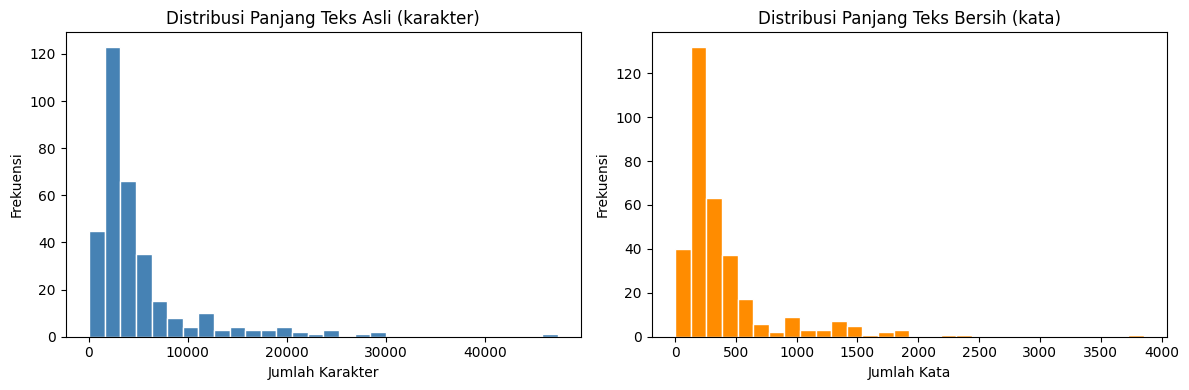

Rata-rata panjang teks asli : 5043 karakter
Rata-rata panjang teks bersih: 395 kata


In [29]:
# Article text length distribution
df['text_length'] = df['text_berita'].fillna('').apply(len)
df['clean_length'] = df['text_berita_clean'].fillna('').apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['text_length'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Panjang Teks Asli (karakter)')
axes[0].set_xlabel('Jumlah Karakter')
axes[0].set_ylabel('Frekuensi')

axes[1].hist(df['clean_length'], bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('Distribusi Panjang Teks Bersih (kata)')
axes[1].set_xlabel('Jumlah Kata')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

print(f"Rata-rata panjang teks asli : {df['text_length'].mean():.0f} karakter")
print(f"Rata-rata panjang teks bersih: {df['clean_length'].mean():.0f} kata")

## 5. Sentiment Analysis dengan IndoBERT

Model yang digunakan: [`apriandito/indobert-sentiment-classifier`](https://huggingface.co/apriandito/indobert-sentiment-classifier)

Model ini adalah IndoBERT yang di-*fine-tune* untuk klasifikasi sentimen Bahasa Indonesia dengan tiga kelas:
- `POSITIF` → **Positif**
- `NETRAL` → **Netral**
- `NEGATIF` → **Negatif**

In [30]:
MODEL_NAME = "apriandito/indobert-sentiment-classifier"

print(f"Loading model: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

sentiment_pipeline = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=device,
    truncation=True,
    max_length=512,
)

LABEL_MAP = {
    'POSITIF': 'Positif',
    'NETRAL': 'Netral',
    'NEGATIF': 'Negatif',
}

print("Model loaded.")

Loading model: apriandito/indobert-sentiment-classifier


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 7927.71it/s]


Model loaded.


In [32]:
CONTEXT = "Program Makan Bergizi Gratis"
torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(torch_device)
model.eval()

# Read label mapping directly from the model's config (avoids hardcoding wrong indices)
LABEL_IDX = {int(k): v for k, v in model.config.id2label.items()}
print("Label mapping:", LABEL_IDX)

def predict_sentiment(texts, batch_size=16):
    """Run sentiment inference with context-conditioned input [CLS] context [SEP] text [SEP]."""
    results = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Predicting"):
        batch = texts[i : i + batch_size]
        batch = [t if isinstance(t, str) and len(t) > 0 else "tidak ada teks" for t in batch]
        encodings = tokenizer(
            [CONTEXT] * len(batch),
            batch,
            truncation=True,
            max_length=256,
            padding=True,
            return_tensors="pt",
        ).to(torch_device)
        with torch.no_grad():
            logits = model(**encodings).logits
            probs = torch.softmax(logits, dim=-1)
            preds = torch.argmax(probs, dim=-1)
            scores = probs[range(len(batch)), preds]
        for pred, score in zip(preds.cpu().numpy(), scores.cpu().numpy()):
            results.append({"label": LABEL_IDX[int(pred)], "score": float(score)})
    return results

texts = df['text_berita'].fillna('').tolist()
raw_preds = predict_sentiment(texts)

df['pred_label_raw'] = [p['label'] for p in raw_preds]
df['pred_score'] = [p['score'] for p in raw_preds]
df['pred_sentiment'] = df['pred_label_raw'].map(LABEL_MAP)

print("\nPredicted sentiment distribution:")
print(df['pred_sentiment'].value_counts())

Label mapping: {0: 'NEGATIF', 1: 'NETRAL', 2: 'POSITIF'}


Predicting: 100%|██████████| 21/21 [00:14<00:00,  1.45it/s]


Predicted sentiment distribution:
pred_sentiment
Netral     182
Positif     91
Negatif     60
Name: count, dtype: int64


## 6. Analisis Hasil Sentimen

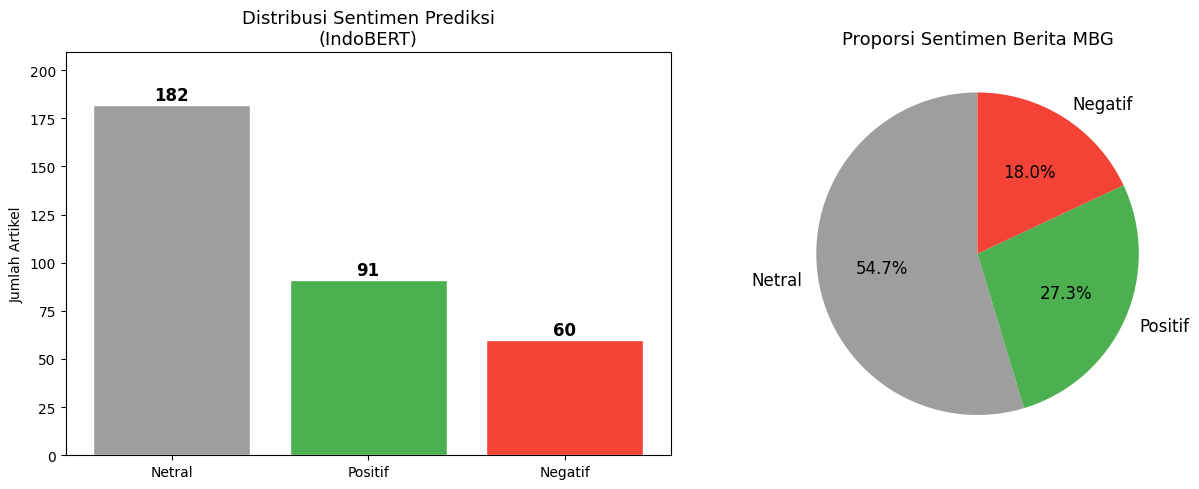

Netral    :  182 (54.7%)
Positif   :   91 (27.3%)
Negatif   :   60 (18.0%)


In [33]:
# Sentiment distribution pie & bar
sent_counts = df['pred_sentiment'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_map = {'Positif': '#4CAF50', 'Netral': '#9E9E9E', 'Negatif': '#F44336'}
colors = [colors_map.get(l, 'steelblue') for l in sent_counts.index]

# Bar chart
bars = axes[0].bar(sent_counts.index, sent_counts.values, color=colors, edgecolor='white')
for bar, val in zip(bars, sent_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_title('Distribusi Sentimen Prediksi\n(IndoBERT)', fontsize=13)
axes[0].set_ylabel('Jumlah Artikel')
axes[0].set_ylim(0, sent_counts.max() * 1.15)

# Pie chart
axes[1].pie(
    sent_counts.values,
    labels=sent_counts.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12},
)
axes[1].set_title('Proporsi Sentimen Berita MBG', fontsize=13)

plt.tight_layout()
plt.show()

total = len(df)
for s, c in sent_counts.items():
    print(f"{s:10s}: {c:4d} ({c/total*100:.1f}%)")

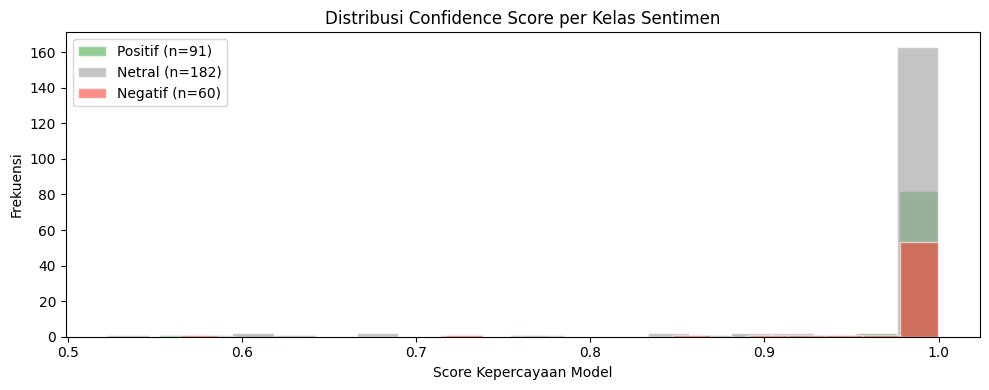

In [34]:
# Confidence score distribution per sentiment class
fig, ax = plt.subplots(figsize=(10, 4))

for sent in ['Positif', 'Netral', 'Negatif']:
    subset = df[df['pred_sentiment'] == sent]['pred_score']
    if len(subset) > 0:
        ax.hist(subset, bins=20, alpha=0.6, label=f'{sent} (n={len(subset)})',
                color=colors_map[sent], edgecolor='white')

ax.set_title('Distribusi Confidence Score per Kelas Sentimen')
ax.set_xlabel('Score Kepercayaan Model')
ax.set_ylabel('Frekuensi')
ax.legend()
plt.tight_layout()
plt.show()

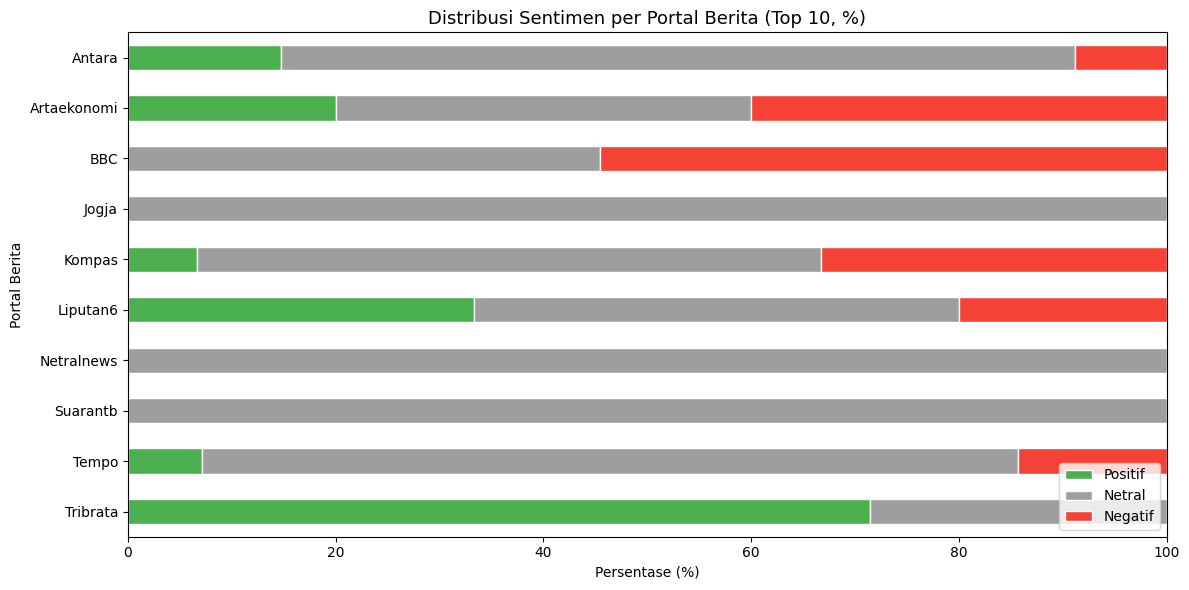

In [35]:
# Sentiment distribution per news portal (top 10 portals)
top_portals = df['portal_berita'].value_counts().head(10).index
df_top = df[df['portal_berita'].isin(top_portals)]

pivot = df_top.groupby(['portal_berita', 'pred_sentiment']).size().unstack(fill_value=0)
# Ensure all columns exist
for col in ['Positif', 'Netral', 'Negatif']:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[['Positif', 'Netral', 'Negatif']]

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
pivot_pct.plot(
    kind='barh',
    stacked=True,
    color=[colors_map['Positif'], colors_map['Netral'], colors_map['Negatif']],
    ax=ax,
    edgecolor='white',
)
ax.set_title('Distribusi Sentimen per Portal Berita (Top 10, %)', fontsize=13)
ax.set_xlabel('Persentase (%)')
ax.set_ylabel('Portal Berita')
ax.legend(loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Evaluasi terhadap Label Manual

Dataset label saat ini **belum lengkap** — hanya sebagian artikel yang sudah diberi label. Evaluasi di bawah membandingkan prediksi model dengan label manual yang tersedia. Seiring label dilengkapi, accuracy dan metrik evaluasi akan menjadi lebih representatif.

In [36]:
# Filter only labeled rows
df_eval = df[df['label'].notna()].copy()
print(f"Artikel berlabel: {len(df_eval)}")

if len(df_eval) == 0:
    print("Belum ada label manual — evaluasi akan tersedia saat dataset dilengkapi.")
else:
    display(df_eval[['judul', 'portal_berita', 'label', 'pred_sentiment', 'pred_score']]
            .rename(columns={'label': 'label_manual', 'pred_sentiment': 'pred_IndoBERT'}))

Artikel berlabel: 331


,judul,portal_berita,label_manual,pred_IndoBERT,pred_score
0,Wamendukbangga: Distribusi MBG untuk Ibu Hamil...,Tribrata,Positif,Positif,0.996203
1,Makan Gratis dan Pertaruhan Politik Anggaran |...,Tempo,Negatif,Negatif,0.999555
2,Pedagang Melon di Pasar Gede Solo Rasakan Peni...,Liputan6,Positif,Positif,0.999881
3,"Melihat Praktik Kyushoku, Program MBG di Jepan...",Artaekonomi,Netral,Positif,0.999765
4,Anak Bukan Angka: Kritik Ibu atas Program Maka...,Bandungbergerak,Negatif,Netral,0.999819
...,...,...,...,...,...
328,Wamenkes Sebut 4.535 Dapur MBG Sudah Kantongi ...,Liputan6,Positif,Positif,0.998706
329,Rakor penyelenggaraan program MBG di Jawa Timur,Antara,Netral,Netral,0.999886
330,"Pegawai SPPG Berpeluang Diangkat ASN, Ini Dasa...",Banpos,Netral,Netral,0.975896
331,Ketika Ahli Gizi dan Akuntan MBG Lebih Priorit...,Inanews,Negatif,Negatif,0.998926


Classification Report
              precision    recall  f1-score   support

     Positif       0.77      0.62      0.69       113
      Netral       0.48      0.81      0.60       107
     Negatif       0.92      0.49      0.64       111

    accuracy                           0.64       331
   macro avg       0.72      0.64      0.64       331
weighted avg       0.72      0.64      0.64       331



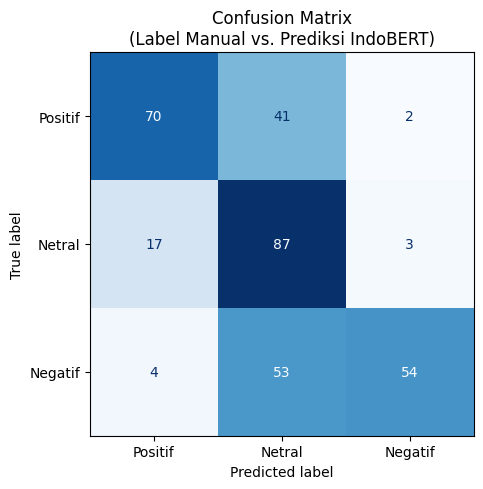

In [37]:
if len(df_eval) > 0:
    y_true = df_eval['label'].tolist()
    y_pred = df_eval['pred_sentiment'].tolist()
    labels_order = ['Positif', 'Netral', 'Negatif']

    print("=" * 50)
    print("Classification Report")
    print("=" * 50)
    print(classification_report(
        y_true, y_pred,
        labels=labels_order,
        zero_division=0
    ))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=labels_order)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title('Confusion Matrix\n(Label Manual vs. Prediksi IndoBERT)')
    plt.tight_layout()
    plt.show()
else:
    print("Confusion matrix akan ditampilkan setelah dataset dilengkapi.")

## 8. Word Cloud per Kelas Sentimen

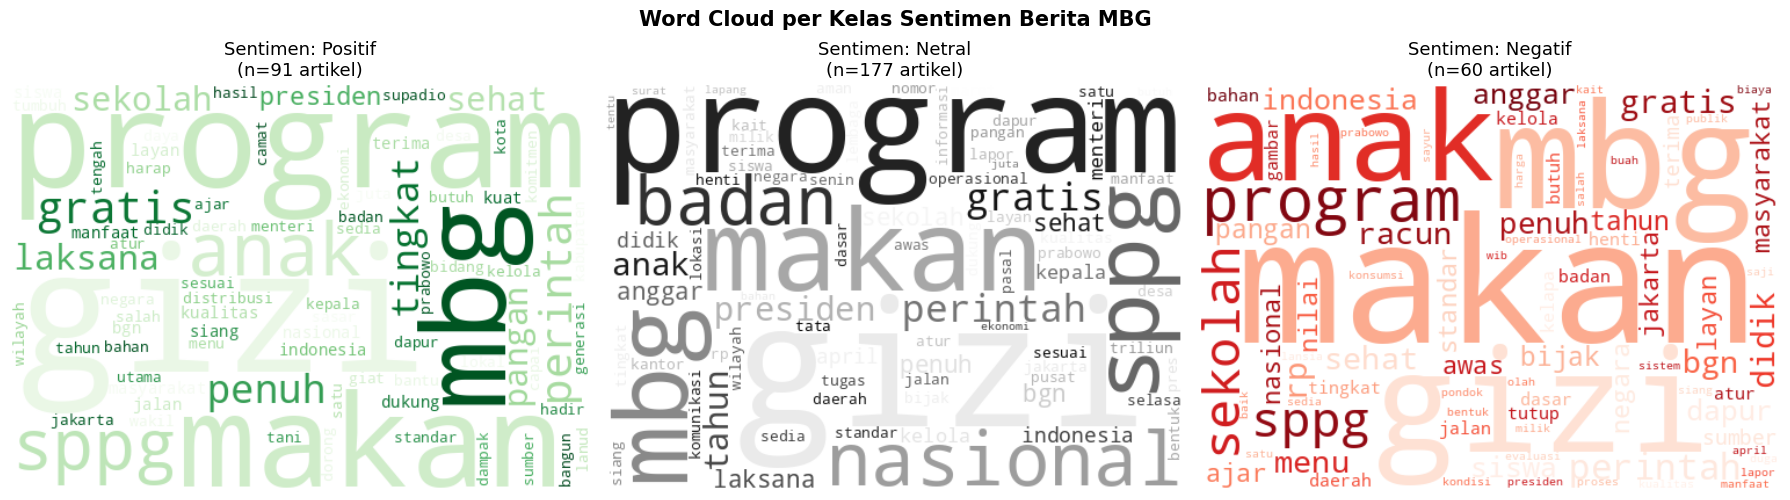

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sentiment_classes = ['Positif', 'Netral', 'Negatif']
wc_colors = {'Positif': 'Greens', 'Netral': 'Greys', 'Negatif': 'Reds'}

for ax, sent in zip(axes, sentiment_classes):
    subset = df[df['pred_sentiment'] == sent]['text_berita_clean'].dropna()
    combined_text = ' '.join(subset.tolist())

    if len(combined_text.strip()) == 0:
        ax.text(0.5, 0.5, f'Tidak ada artikel {sent}', ha='center', va='center')
        ax.set_title(sent)
        ax.axis('off')
        continue

    wc = WordCloud(
        width=500, height=350,
        background_color='white',
        colormap=wc_colors[sent],
        max_words=80,
        collocations=False,
    ).generate(combined_text)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Sentimen: {sent}\n(n={len(subset)} artikel)', fontsize=13)
    ax.axis('off')

plt.suptitle('Word Cloud per Kelas Sentimen Berita MBG', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Top Artikel per Kelas Sentimen

In [39]:
for sent in sentiment_classes:
    subset = df[df['pred_sentiment'] == sent].nlargest(5, 'pred_score')
    if len(subset) == 0:
        continue
    print(f"\n{'='*60}")
    print(f"TOP 5 — {sent} (confidence tertinggi)")
    print('='*60)
    for _, row in subset.iterrows():
        title = str(row['judul'])[:80]
        portal = str(row['portal_berita'])
        score = row['pred_score']
        print(f"  [{score:.3f}] {title}")
        print(f"          Portal: {portal}")
        print()


TOP 5 — Positif (confidence tertinggi)
  [1.000] SPPG Karamat Rayakan Keberhasilan SMAN 2 Sukabumi sebagai Sekolah Terbaik Jawa B
          Portal: Sukabumiku

  [1.000] Food Truck Universitas Diponegoro: Makan Siang Gratis untuk Mahasiswa - Universi
          Portal: Undip

  [1.000] Ratusan Siswa MTsN 17 Jakarta Antusias Sambut Hari Pertama Program Makan Bergizi
          Portal: Dki

  [1.000] Program Makan Bergizi Gratis: Investasi Gizi dan Ekonomi Daerah - Media Keuangan
          Portal: Mediakeuangan

  [1.000] Surabaya Dukung Penuh Program MBG Nasional: Tak hanya Makan Gratis, Tapi Bentuk 
          Portal: Surabaya


TOP 5 — Netral (confidence tertinggi)
  [1.000] Sosok Dadan Hindayana yang Dilantik Jokowi Menjadi Kepala Badan Gizi Nasional | 
          Portal: Tempo

  [1.000] Prabowo Mau Bikin 3 Badan Baru di Pemerintahan Mendatang, Apa Saja? | tempo.co
          Portal: Tempo

  [1.000] Kepala Badan Gizi Nasional Menginstruksikan Dapur MBG Harus
          Portal: Tribrata


## 10. Analisis Kata Kunci per Sentimen (TF-IDF)

Menggunakan TF-IDF untuk menemukan kata yang paling membedakan setiap kelas sentimen.

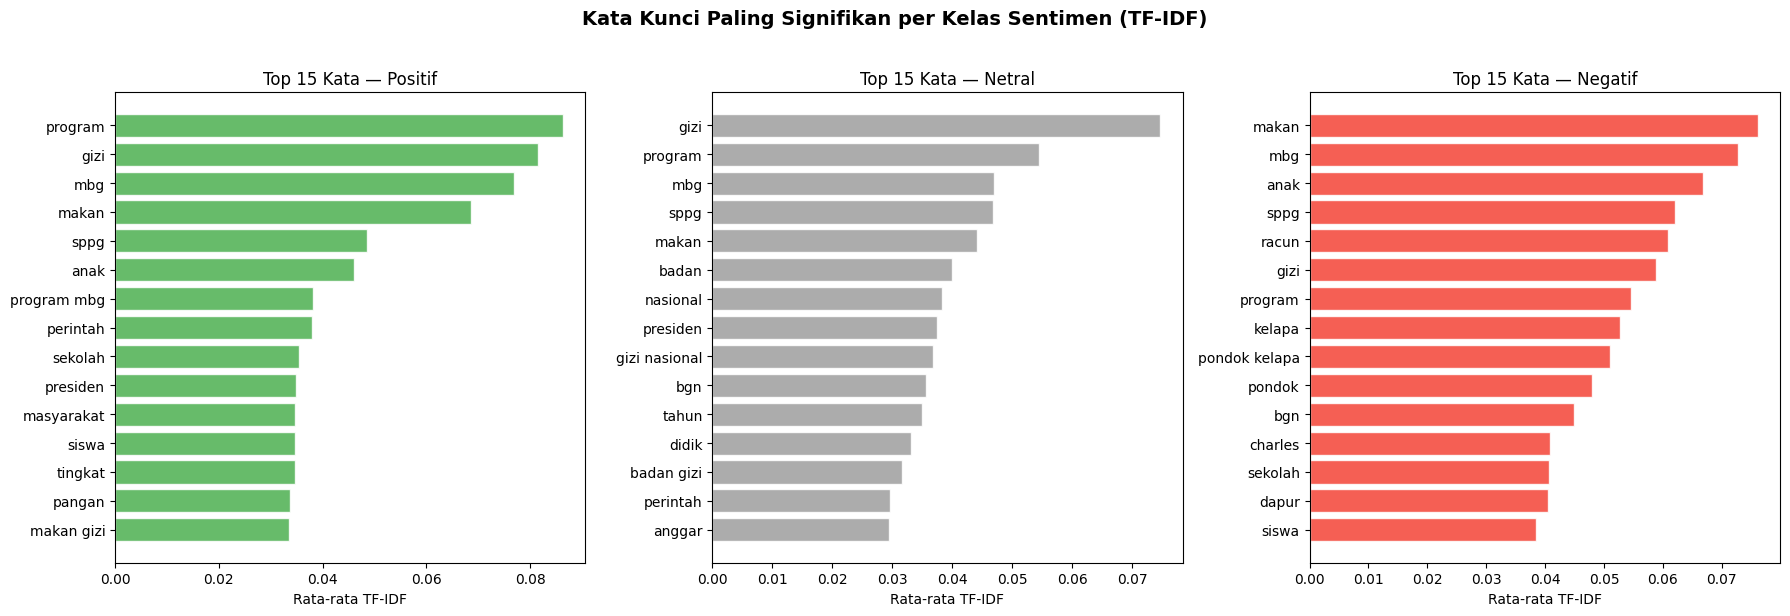

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Build per-class corpus
corpus = {}
for sent in sentiment_classes:
    texts_sent = df[df['pred_sentiment'] == sent]['text_berita_clean'].dropna().tolist()
    corpus[sent] = texts_sent

# Fit TF-IDF on entire dataset, then extract top terms per class
all_texts = df['text_berita_clean'].fillna('').tolist()
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
tfidf.fit(all_texts)
feature_names = tfidf.get_feature_names_out()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, sent in zip(axes, sentiment_classes):
    if len(corpus[sent]) == 0:
        ax.text(0.5, 0.5, f'Tidak ada artikel', ha='center', va='center')
        ax.set_title(sent)
        continue

    X = tfidf.transform(corpus[sent])
    mean_tfidf = X.mean(axis=0).A1
    top_indices = mean_tfidf.argsort()[-15:][::-1]
    top_words = [feature_names[i] for i in top_indices]
    top_scores = [mean_tfidf[i] for i in top_indices]

    color = colors_map[sent]
    bars = ax.barh(range(len(top_words)), top_scores[::-1],
                   color=color, edgecolor='white', alpha=0.85)
    ax.set_yticks(range(len(top_words)))
    ax.set_yticklabels(top_words[::-1], fontsize=10)
    ax.set_title(f'Top 15 Kata — {sent}', fontsize=12)
    ax.set_xlabel('Rata-rata TF-IDF')

plt.suptitle('Kata Kunci Paling Signifikan per Kelas Sentimen (TF-IDF)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 11. Simpan Hasil

In [41]:
output_cols = [
    'judul', 'link', 'portal_berita',
    'pred_sentiment', 'pred_score',
    'label',  # manual label (NaN where not yet filled)
    'text_berita_clean',
]

df_out = df[output_cols].rename(columns={
    'pred_sentiment': 'sentimen_prediksi',
    'pred_score'    : 'confidence',
    'label'         : 'label_manual',
})

out_path = 'sentiment_results.csv'
df_out.to_csv(out_path, index=False)
print(f"Results saved to: {out_path}")
print(f"Total rows: {len(df_out)}")
df_out.head()

Results saved to: sentiment_results.csv
Total rows: 333


,judul,link,portal_berita,sentimen_prediksi,confidence,label_manual,text_berita_clean
0,Wamendukbangga: Distribusi MBG untuk Ibu Hamil...,https://tribratanews.polri.go.id/blog/nasional...,Tribrata,Positif,0.996203,Positif,tribratanews polri go id jakarta wakil menteri...
1,Makan Gratis dan Pertaruhan Politik Anggaran |...,https://www.tempo.co/kolom/mbg-dan-pertaruhan-...,Tempo,Negatif,0.999555,Negatif,wakil rektor universitas paramadina lulus prog...
2,Pedagang Melon di Pasar Gede Solo Rasakan Peni...,https://www.liputan6.com/regional/read/6310544...,Liputan6,Positif,0.999881,Positif,dagang buah pasar gede hardjonagoro solo rasa ...
3,"Melihat Praktik Kyushoku, Program MBG di Jepan...",https://wartaekonomi.co.id/read606799/melihat-...,Artaekonomi,Positif,0.999765,Netral,program makan gizi gratis mbg indonesia perint...
4,Anak Bukan Angka: Kritik Ibu atas Program Maka...,https://bandungbergerak.id/article/detail/1546...,Bandungbergerak,Netral,0.999819,Negatif,program makan gizi gratis mbg distribusi kuali...


## 12. Ringkasan

| Aspek | Detail |
|---|---|
| **Dataset** | 337 berita MBG hasil scraping (Week 6) |
| **Model** | `apriandito/indobert-sentiment-classifier` (IndoBERT fine-tuned) |
| **Kelas** | Positif / Netral / Negatif |
| **Evaluasi** | Label manual tersedia untuk sebagian artikel; akan diperbarui saat dataset dilengkapi |

### Interpretasi
- **Positif**: Artikel yang meliput capaian, dukungan, atau dampak positif program MBG
- **Netral**: Artikel yang bersifat informatif/deskriptif tanpa opini kuat
- **Negatif**: Artikel yang meliput keracunan, kritik, kegagalan implementasi, atau kontroversi MBG

### Catatan Evaluasi
Karena dataset label belum lengkap, akurasi model belum dapat diklaim secara statistik. Seiring bertambahnya label manual:
1. Jalankan ulang **Cell 7 (Evaluasi)** — metrik classification report & confusion matrix akan otomatis diperbarui
2. Jika akurasi rendah, pertimbangkan fine-tuning IndoBERT dengan data berlabel ini